<a href="https://colab.research.google.com/github/ErnyBSB/embeddingModelComparing/blob/main/AssessEmbeddingsModels_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sentence_transformers import SentenceTransformer, util
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# URL do arquivo CSV 'raw' no GitHub
csv_url = 'https://raw.githubusercontent.com/C4AI/Pira/main/Pira1.0/CSV/Pir%C3%A1-F-Total.csv'

# Importar o dataset usando pandas, especificando ',' como separador
df_pira = pd.read_csv(csv_url, sep=',')


  id_qa  corpus                                 question_en_origin  \
0  A363       1  What was the first oil field discovered in Bra...   
1  A884       1  What is one of the concerns of Brazil's govern...   
2  A253       1  In 2014, Petrobras planned to spend e $224 bil...   
3  A640       1  What was the objective of the pioneer interven...   
4  A315       1  How is the torpedo anchor installed on the sea...   

                                  question_pt_origin  \
0  Qual foi o primeiro campo de petróleo descober...   
1  Qual é uma das preocupações do governo brasile...   
2  Em 2014, a Petrobras planejava gastar e $ 224 ...   
3  Qual foi o objetivo da intervenção pioneira no...   
4  Como a âncora torpedo é instalada no fundo do ...   

                               question_en_paraphase  \
0      What was Brazil's first discovered oil field?   
1  what could be one of Brazilian government's co...   
2  What did Petrobras BR want to spend $224 billi...   
3                 

In [ ]:
print('--- Detalhes do DataFrame df_pira ---\n')

# Número total de linhas e colunas
linhas, colunas = df_pira.shape
print(f'Total de linhas: {linhas}')
print(f'Total de colunas: {colunas}\n')

# Informações gerais do DataFrame (tipos de dados, valores não nulos)
print('Informações gerais (df_pira.info()):')
df_pira.info()

print('\n--- Estatísticas Descritivas (df_pira.describe()) ---\n')
# Estatísticas descritivas para colunas numéricas
print(df_pira.describe())

print('\n--- Contagem de Valores Ausentes por Coluna (df_pira.isnull().sum()) ---\n')
# Contagem de valores ausentes por coluna
print(df_pira.isnull().sum())

--- Detalhes do DataFrame df_pira ---

Total de linhas: 1346
Total de colunas: 18

Informações gerais (df_pira.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1346 entries, 0 to 1345
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   id_qa                     1346 non-null   object
 1   corpus                    1346 non-null   int64 
 2   question_en_origin        1346 non-null   object
 3   question_pt_origin        1346 non-null   object
 4   question_en_paraphase     1236 non-null   object
 5   question_pt_paraphase     1236 non-null   object
 6   answer_en_origin          1346 non-null   object
 7   answer_pt_origin          1346 non-null   object
 8   answer_en_validate        1212 non-null   object
 9   answer_pt_validate        1212 non-null   object
 10  eid_article_scopus        961 non-null    object
 11  text_excerpts_un_reports  385 non-null    object
 12  question_gen

In [ ]:
# 1. Define Models to Compare:
#
# - 'paraphrase-multilingual-MiniLM-L12-v2': Atual, Multilíngue
# - 'distiluse-base-multilingual-cased-v1': Novo, Multilíngue
# - 'all-MiniLM-L6-v2': Novo, Monolíngue (Inglês)

model_names = {
    'Multilingual-MiniLM': 'paraphrase-multilingual-MiniLM-L12-v2',
    'Multilingual-DistilUSE': 'distiluse-base-multilingual-cased-v1',
    'English-MiniLM': 'all-MiniLM-L6-v2' # Este não é multilíngue
}

In [ ]:
corpus_answer_en_origin = df_pira['answer_en_origin'].tolist()

# Opcional: Para verificar as primeiras entradas da lista e seu tamanho
print(f"Primeiras 5 entradas de corpus_answer_en_origin: {corpus_answer_en_origin[:5]}")
print(f"Tamanho de corpus_answer_en_origin: {len(corpus_answer_en_origin)}")

Primeiras 5 entradas de corpus_answer_en_origin: ['The Lobito oil field.', 'To maintain the interest of foreign investors in Brazil', "The effort aimed to develop Brazil's oil services sector.", 'The objective was to increase oil production and decrease water cut.', 'Using kinetic energy obtained by free-falling into the water.']
Tamanho de corpus_answer_en_origin: 1346


In [ ]:
corpus_answer_pt_origin = df_pira['answer_pt_origin'].tolist()

# Opcional: Para verificar as primeiras entradas da lista e seu tamanho
print(f"Primeiras 5 entradas de corpus_answer_pt_origin: {corpus_answer_pt_origin[:5]}")
print(f"Tamanho de corpus_answer_pt_origin: {len(corpus_answer_pt_origin)}")

Primeiras 5 entradas de corpus_answer_pt_origin: ['O campo de petróleo Lobito.', 'Manter o interesse de investidores estrangeiros no Brasil', 'O objetivo da iniciativa era o de desenvolver a indústria petrolífera brasileira.', 'O objetivo era aumentar a produção de óleo e diminuir o corte de água.', 'Usando energia cinética obtida por queda livre na água.']
Tamanho de corpus_answer_pt_origin: 1346


In [ ]:
print('Iniciando o cálculo da Similaridade de Cossenos para cada modelo e corpus...')

results = {}

for model_alias, model_name in model_names.items():
    print(f'\nProcessando modelo: {model_alias} ({model_name})')
    model = SentenceTransformer(model_name)

    # Gerar embeddings para o corpus em português
    print(f'Gerando embeddings para corpus_answer_pt_origin com {model_alias}...')
    embeddings_pt = model.encode(corpus_answer_pt_origin, convert_to_tensor=True)

    # Gerar embeddings para o corpus em inglês
    print(f'Gerando embeddings para corpus_answer_en_origin com {model_alias}...')
    embeddings_en = model.encode(corpus_answer_en_origin, convert_to_tensor=True)

    # Calcular a similaridade de cossenos entre os embeddings em português e inglês
    # Usamos util.pytorch_cos_sim que é otimizado para tensores PyTorch
    cosine_scores = util.pytorch_cos_sim(embeddings_pt, embeddings_en)

    # Para este caso, como queremos comparar a similaridade entre pares correspondentes (um a um)
    # estamos interessados nos elementos da diagonal principal da matriz de similaridade,
    # onde a i-ésima frase em PT é comparada com a i-ésima frase em EN.
    # No entanto, a função pytorch_cos_sim irá retornar uma matriz (n_pt, n_en)
    # Para comparação um-a-um, basta extrair a diagonal.
    # Mas se a intenção é ver a similaridade de cada PT com cada EN (matriz completa),
    # então 'cosine_scores' já é a matriz desejada.
    # Para a sua solicitação 'comparando o quanto os cossenos são similares ou não',
    # interpretarei como a similaridade entre os pares correspondentes (i,i).

    # Extrair os scores da diagonal (comparação pareada)
    # Assumimos que embeddings_pt[i] corresponde a embeddings_en[i]
    paired_cosine_scores = [cosine_scores[i][i].item() for i in range(len(corpus_answer_pt_origin))]

    results[model_alias] = {
        'mean_cosine_similarity': np.mean(paired_cosine_scores),
        'std_cosine_similarity': np.std(paired_cosine_scores),
        'min_cosine_similarity': np.min(paired_cosine_scores),
        'max_cosine_similarity': np.max(paired_cosine_scores)
    }

    print(f'Estatísticas de similaridade para {model_alias}:')
    print(f"  Média: {results[model_alias]['mean_cosine_similarity']:.4f}")
    print(f"  Desvio Padrão: {results[model_alias]['std_cosine_similarity']:.4f}")
    print(f"  Mínimo: {results[model_alias]['min_cosine_similarity']:.4f}")
    print(f"  Máximo: {results[model_alias]['max_cosine_similarity']:.4f}")


print('\nResumo dos resultados da Similaridade de Cossenos:')
for model_alias, stats in results.items():
    print(f"Modelo: {model_alias}")
    print(f"  Média de Similaridade de Cossenos: {stats['mean_cosine_similarity']:.4f}")
    print(f"  Desvio Padrão: {stats['std_cosine_similarity']:.4f}")
    print(f"  Mínimo: {stats['min_cosine_similarity']:.4f}")
    print(f"  Máximo: {stats['max_cosine_similarity']:.4f}")


Iniciando o cálculo da Similaridade de Cossenos para cada modelo e corpus...

Processando modelo: Multilingual-MiniLM (paraphrase-multilingual-MiniLM-L12-v2)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Gerando embeddings para corpus_answer_pt_origin com English-MiniLM...
Gerando embeddings para corpus_answer_en_origin com English-MiniLM...
Estatísticas de similaridade para English-MiniLM:
  Média: 0.4403
  Desvio Padrão: 0.2168
  Mínimo: -0.0144
  Máximo: 1.0000

Resumo dos resultados da Similaridade de Cossenos:
Modelo: Multilingual-MiniLM
  Média de Similaridade de Cossenos: 0.8965
  Desvio Padrão: 0.1011
  Mínimo: 0.1680
  Máximo: 1.0000
Modelo: Multilingual-DistilUSE
  Média de Similaridade de Cossenos: 0.9148
  Desvio Padrão: 0.0709
  Mínimo: 0.4368
  Máximo: 1.0000
Modelo: English-MiniLM
  Média de Similaridade de Cossenos: 0.4403
  Desvio Padrão: 0.2168
  Mínimo: -0.0144
  Máximo: 1.0000


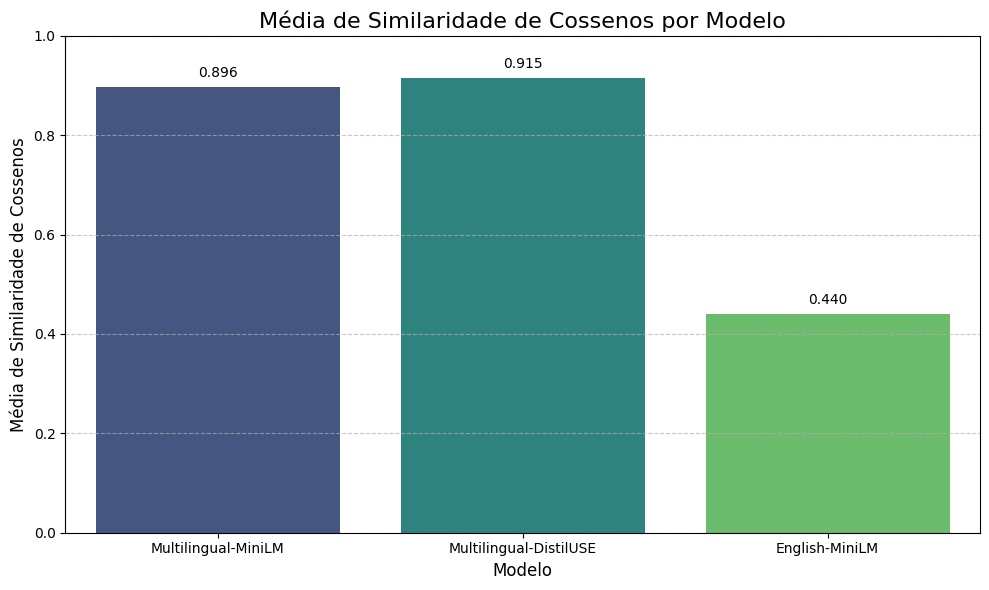

In [ ]:

# Preparar os dados para o gráfico
plot_data = []
for model_alias, stats in results.items():
    plot_data.append({
        'Modelo': model_alias,
        'Média de Similaridade de Cossenos': stats['mean_cosine_similarity']
    })

df_plot = pd.DataFrame(plot_data)

# Criar o gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='Modelo', y='Média de Similaridade de Cossenos', data=df_plot, palette='viridis', hue='Modelo', legend=False)

# Adicionar título e rótulos
plt.title('Média de Similaridade de Cossenos por Modelo', fontsize=16)
plt.xlabel('Modelo', fontsize=12)
plt.ylabel('Média de Similaridade de Cossenos', fontsize=12)
plt.ylim(0, 1) # Similaridade de cossenos varia de -1 a 1

# Adicionar os valores exatos nas barras
for index, row in df_plot.iterrows():
    plt.text(index, row['Média de Similaridade de Cossenos'] + 0.02,
             f"{row['Média de Similaridade de Cossenos']:.3f}", color='black', ha="center")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import nbformat
import os

# --- IMPORTANT: Configure this variable ---
# You *must* replace 'your_notebook_name.ipynb' with the *actual filename* of this notebook.
# To find the filename, look at the tab title in your browser or the file explorer in Colab.
# Example: If your notebook is named 'MyProject.ipynb', change it to 'MyProject.ipynb'.
notebook_filename = 'AssessEmbeddingsModels_04.ipynb' # <--- REPLACE THIS WITH YOUR NOTEBOOK'S FILENAME!

# --- Script to clean metadata (no changes needed below this line) ---

if not os.path.exists(notebook_filename):
    print(f"Error: Notebook file '{notebook_filename}' not found. Please ensure the filename is correct and in the same directory as this script.")
else:
    try:
        with open(notebook_filename, 'r', encoding='utf-8') as f:
            notebook = nbformat.read(f, as_version=4)

        cleaned_cells_count = 0
        for cell in notebook.cells:
            if 'metadata' in cell and 'widgets' in cell['metadata']:
                del cell['metadata']['widgets']
                cleaned_cells_count += 1

        with open(notebook_filename, 'w', encoding='utf-8') as f:
            nbformat.write(notebook, f)

        print(f"Successfully cleaned '{cleaned_cells_count}' cells in '{notebook_filename}'.")
        print("The 'metadata.widgets' key has been removed from the notebook. Please save your notebook and try rendering it on GitHub again.")
    except Exception as e:
        print(f"An error occurred during cleaning: {e}")
        print("Please check the notebook file for integrity or try saving it again.")

Error: Notebook file 'AssessEmbeddingsModels_04.ipynb' not found. Please ensure the filename is correct and in the same directory as this script.


In [ ]:
import os

notebook_filename = 'AssessEmbeddingsModels_04.ipynb'

print(f"Contents of '/content/': {os.listdir('/content/')}")

if notebook_filename in os.listdir('/content/'):
    print(f"The file '{notebook_filename}' was found in '/content/'.")
else:
    print(f"The file '{notebook_filename}' was NOT found in '/content/'. Please make sure the notebook is saved and that its actual name matches this variable.")


Contents of '/content/': ['.config', 'sample_data']
The file 'AssessEmbeddingsModels_04.ipynb' was NOT found in '/content/'. Please make sure the notebook is saved and that its actual name matches this variable.


First, you need to mount your Google Drive to access your notebook file. A prompt will appear asking you to authorize Colab to access your Drive. Follow the instructions to complete the mounting process.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Now that your Drive is mounted, we need to find the full path to your notebook file. By default, Colab notebooks are saved in 'My Drive/Colab Notebooks'. You might need to adjust this path if you saved it elsewhere.

Once you confirm the path, we will copy the notebook file to the `/content` directory.

In [ ]:
# Replace 'AssessEmbeddingsModels_04.ipynb' with the exact name of your notebook if it's different.
notebook_name = 'AssessEmbeddingsModels_04.ipynb'

# This is a common path for Colab notebooks in Google Drive. Adjust if yours is different.
source_path = f'/content/drive/MyDrive/Colab Notebooks/{notebook_name}'
destination_path = '/content/'

import shutil
import os

if os.path.exists(source_path):
    try:
        shutil.copy(source_path, destination_path)
        print(f"Successfully copied '{notebook_name}' from Drive to '{destination_path}'.")
        # Now that it's copied, you can re-run the cleaning script.
    except Exception as e:
        print(f"An error occurred while copying the file: {e}")
else:
    print(f"Error: Source file '{source_path}' not found. Please check if the notebook is in 'My Drive/Colab Notebooks' or update the 'source_path' variable with the correct location in your Google Drive.")